# Computing an escape time landscape

This is a first try with some tests and experimentation to find the best way to compute and plot the values

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import rebound

from src.integrator.integrate import phi
from src.utils.boundary import B2_v_func

In [2]:
def number_returns_before_escape(e, v0, t0, max_ret = 100, t_max = 100):
    '''
    Returns the number of returns to z=0 (capped at max_iter)
    before the particle takes t_max or longer to return.
    '''
    i = 0
    v = v0
    t = t0

    while v is not None and i < max_ret:
        v, t = phi(e, v, t, t_max = t_max)
        i += 1
    
    if v is None:
        return i - 1
    else:
        return max_ret

Choose an eccentricity and load the boundary function

In [5]:
e = 0.5
B2_v = B2_v_func(e, dv = 1e-3, N_t = 100)

From my first experiment it seems like time to compute is approx $aN_v N_t max_{ret}$ with $a$ around 0.05
Empirical estimates of a = 23/500, 243/4500


In [55]:
N_t = 40
N_v = 20
max_ret = 20
t_max = 10

# -- 1. Setup Grid Edges for Plotting (Mesh) --
# Dimensions: (N_v + 1, N_t + 1)
theta_edges = np.linspace(0, 2*np.pi, N_t + 1)

t_mesh = np.zeros((N_v + 1, N_t + 1))
v_mesh = np.zeros((N_v + 1, N_t + 1))

for j, t in enumerate(theta_edges):
    t_mesh[:, j] = t
    v_limit = B2_v(t)
    v_mesh[:, j] = np.linspace(0, v_limit, N_v + 1)

# -- 2. Setup Centers for Computation --
# Dimensions: (N_v, N_t)
t_comp = np.zeros((N_v, N_t))
v_comp = np.zeros((N_v, N_t))
ret_grid = np.zeros((N_v, N_t))

for j in range(N_t):
    # Midpoint angle
    t_c = 0.5 * (theta_edges[j] + theta_edges[j+1])
    t_comp[:, j] = t_c
    
    # Midpoint radius (at the center angle)
    v_lim_c = B2_v(t_c)
    # The radial bins are proportional. 0 to 1/Nv, 1/Nv to 2/Nv...
    # Center of k-th bin is (k + 0.5)/Nv * v_limit
    radial_centers = np.linspace(0, v_lim_c, N_v + 1)
    radial_centers = 0.5 * (radial_centers[:-1] + radial_centers[1:])
    v_comp[:, j] = radial_centers

for i in range(N_v):
    for j in range(N_t):
        t = t_comp[i][j]
        v = v_comp[i][j]
        ret_grid[i][j] = 20*v

Text(0.5, 1.1, 'Escape time landscape e=0.5')

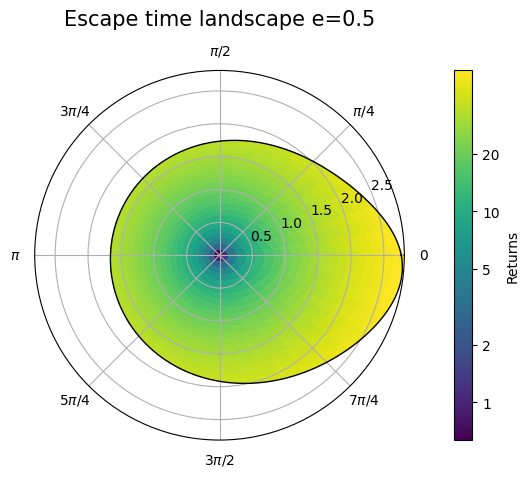

In [ ]:
from matplotlib.colors import SymLogNorm

fig, ax = plt.subplots(subplot_kw={'projection':'polar'})

# Use the mesh edges (t_mesh, v_mesh) which have shape (N_v+1, N_t+1)
# ret_grid has shape (N_v, N_t)
# This ensures the first row of cells starts exactly at v=0
mesh = ax.pcolormesh(t_comp, v_comp, ret_grid, norm=SymLogNorm(linthresh=1.0), cmap='viridis')

ax.set_xticks(np.linspace(0, 2*np.pi, 8, endpoint=False))
ax.set_xticklabels(["0", "$\\pi$/4", "$\\pi$/2", "$3\\pi$/4", "$\\pi$", "$5\\pi$/4", "$3\\pi$/2", "$7\\pi$/4"])

# Define your custom ticks
custom_ticks = [0, 1, 2, 5, 10, 20]

# Pass them to the colorbar
cbar = fig.colorbar(mesh, ax=ax, label='Returns', ticks=custom_ticks, pad=0.1)

# Optional: If the labels look weird, force them to be simple strings
cbar.ax.set_yticklabels([str(t) for t in custom_ticks])

# Plot the boundary around it
t_bound_vals = np.linspace(0, 2*np.pi, 500)
v_bound_vals = B2_v(t_bound_vals)
ax.plot(t_bound_vals, v_bound_vals, color='black', linewidth=1)
ax.set_title(f"Escape time landscape e={e}", size = 15, y=1.1)

In [31]:
print(t_grid)
print(v_grid)

[[0.         0.62831853 1.25663706 1.88495559 2.51327412 3.14159265
  3.76991118 4.39822972 5.02654825 5.65486678]
 [0.         0.62831853 1.25663706 1.88495559 2.51327412 3.14159265
  3.76991118 4.39822972 5.02654825 5.65486678]]
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [1.38241219 1.0640237  0.9056558  0.84401774 0.82387341 0.82947652
  0.85802749 0.91499345 1.01837355 1.21265032]]


In [30]:
import os

data_dir = 'data'

# Construct a descriptive filename
filename = f'escape_time_e{e}_Nt{N_t}_Nv{N_v}.npz'
filepath = os.path.join(data_dir, filename)

# Save the arrays and parameters in a compressed format
np.savez_compressed(filepath, 
                    t_grid=t_grid, 
                    v_grid=v_grid, 
                    ret_grid=ret_grid, 
                    e=e, 
                    N_t=N_t, 
                    N_v=N_v, 
                    max_ret=max_ret, 
                    t_max=t_max)

print(f"Data saved to {filepath}")

Data saved to data\escape_time_e0.5_Nt30_Nv30.npz


In [35]:
data = np.load('data/escape_time_e0.5_Nt30_Nv30.npz')
print(data.files)

['t_grid', 'v_grid', 'ret_grid', 'e', 'N_t', 'N_v', 'max_ret', 't_max']
